## Model Exp 4


In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tkinter import Tk, filedialog # Untuk pop-up pilih file

# ==========================================
# 1. KONFIGURASI
# ==========================================
# Ganti dengan path model .keras Anda yang paling bagus
MODEL_PATH = r'Exp2_DenseNet121_Texture_best_model.keras'

# Ukuran gambar (HARUS SAMA dengan saat training)
IMG_SIZE = (224, 224)

# Daftar Label (Pastikan urutannya benar, biasanya urut abjad folder)
# Sesuaikan dengan nama folder di Google Drive/Hardisk Anda
class_names = [
    'Segar', 'Tidak Segar'
]

# ==========================================
# 2. FUNGSI PREDIKSI
# ==========================================
def predict_image(model, image_path):
    try:
        # A. Muat & Preprocess Gambar
        # Target size harus sama dengan input shape model
        img_original = load_img(image_path)
        img = load_img(image_path, target_size=IMG_SIZE)
        
        # Ubah ke Array
        x = img_to_array(img)
        
        # PENTING: Normalisasi (0-255 -> 0-1)
        # Kalau ini lupa, hasil prediksi bakal ngaco!
        x = x / 255.0
        
        # Tambah dimensi Batch (karena model minta input [Batch, Height, Width, Channel])
        # Dari (150, 150, 3) menjadi (1, 150, 150, 3)
        x = np.expand_dims(x, axis=0)
        
        # B. Prediksi
        predictions = model.predict(x)
        score = tf.nn.softmax(predictions[0]) # Ubah jadi probabilitas
        
        # Ambil index dengan nilai tertinggi
        predicted_class_idx = np.argmax(predictions[0])
        predicted_label = class_names[predicted_class_idx]
        confidence = np.max(predictions[0]) * 100 # Persentase

        # C. Tampilkan Hasil
        plt.figure(figsize=(6, 6))
        plt.imshow(img_original)
        plt.axis('off')
        
        result_text = f"Prediksi: {predicted_label}\nConfidence: {confidence:.2f}%"
        plt.title(result_text, color='green' if confidence > 80 else 'red', fontsize=14)
        plt.show()
        
        print(f"\n---> HASIL: {predicted_label}")
        print(f"---> Yakin: {confidence:.2f}%")
        
        # Tampilkan detail probabilitas semua kelas (opsional)
        print("\nDetail Probabilitas:")
        for i, prob in enumerate(predictions[0]):
            print(f"{class_names[i]}: {prob*100:.2f}%")
            
    except Exception as e:
        print(f"Error: {e}")

Sedang memuat model... (Tunggu sebentar)
✅ Model berhasil dimuat!

Memproses: C:/Users/Azvadennys/Desktop/Training ikan segar/DATASET/Tidak Segar/2026-01-09 18-33-40 (6-2).PNG
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


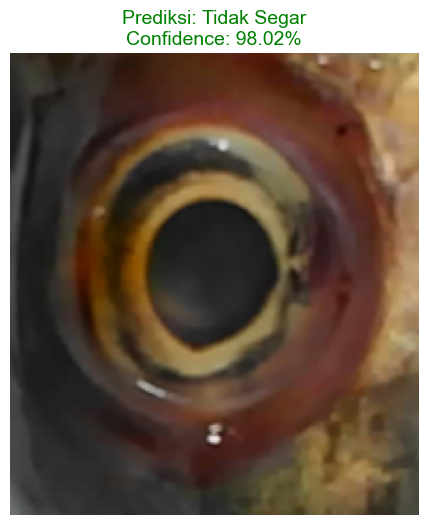


---> HASIL: Tidak Segar
---> Yakin: 98.02%

Detail Probabilitas:
Segar: 1.98%
Tidak Segar: 98.02%


In [4]:
if not os.path.exists(MODEL_PATH):
        print(f"❌ Model tidak ditemukan di: {MODEL_PATH}")
        print("Harap perbaiki path MODEL_PATH di bagian atas kode.")
else:
    print("Sedang memuat model... (Tunggu sebentar)")
    model = tf.keras.models.load_model(MODEL_PATH)
    print("✅ Model berhasil dimuat!")

    while True:
        choice = input("\nTekan [ENTER] untuk pilih gambar, atau ketik 'q' untuk keluar: ")
        if choice.lower() == 'q':
            break
            
        # Buka jendela file picker
        root = Tk()
        root.withdraw() # Sembunyikan jendela utama Tkinter
        root.attributes('-topmost', True) # Agar pop-up muncul di paling depan
            
        file_path = filedialog.askopenfilename(
            title="Pilih Gambar Edible Film",
            filetypes=[("Image Files", "*.png;*.jpg;*.jpeg;*.bmp")]
        )
            
        if file_path:
            print(f"\nMemproses: {file_path}")
            predict_image(model, file_path)
        else:
            print("Tidak ada file yang dipilih.")

# Convert to TF LITE

In [9]:
import tensorflow as tf
import numpy as np
import os

# ==========================================
# 1. KONFIGURASI
# ==========================================
# Path model .keras terbaik Anda
MODEL_PATH = r'Exp4_DenseNet121_Texture_final_model.keras' 
TFLITE_PATH = 'model_edible.tflite'
LABELS_PATH = 'labels.txt'

# Daftar Kelas (Harus urut Abjad sesuai folder Training!)
class_names = [
    'Variasi 1 BAIK', 'Variasi 1 BURUK',
    'Variasi 2 BAIK', 'Variasi 2 BURUK',
    'Variasi 3 BAIK', 'Variasi 3 BURUK',
    'Variasi 4 BAIK', 'Variasi 4 BURUK',
    'Variasi 5 BAIK', 'Variasi 5 BURUK'
]

# ==========================================
# 2. PROSES KONVERSI
# ==========================================
print(f"Loading model dari: {MODEL_PATH}")
model = tf.keras.models.load_model(MODEL_PATH)

# Konverter
converter = tf.lite.TFLiteConverter.from_keras_model(model)

# (Opsional) Optimasi agar file lebih kecil & cepat di HP
converter.optimizations = [tf.lite.Optimize.DEFAULT]

print("Sedang mengonversi ke TFLite...")
tflite_model = converter.convert()

# Simpan File .tflite
with open(TFLITE_PATH, 'wb') as f:
    f.write(tflite_model)
print(f"✅ Sukses! Model TFLite disimpan: {TFLITE_PATH}")

# Simpan File labels.txt
with open(LABELS_PATH, 'w') as f:
    for label in class_names:
        f.write(label + '\n')
print(f"✅ Sukses! Label disimpan: {LABELS_PATH}")

Loading model dari: Exp4_DenseNet121_Texture_final_model.keras
Sedang mengonversi ke TFLite...
INFO:tensorflow:Assets written to: C:\Users\AZVADE~1\AppData\Local\Temp\tmpvvoiam3a\assets


INFO:tensorflow:Assets written to: C:\Users\AZVADE~1\AppData\Local\Temp\tmpvvoiam3a\assets


Saved artifact at 'C:\Users\AZVADE~1\AppData\Local\Temp\tmpvvoiam3a'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  2418207641264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2418207667824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2418207675840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2418207666944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2418207667648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2418207703104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2418207705040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2418207690064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2418207703984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2418207718560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  

## Ekstrak Citra

In [8]:
!pip install opencv-python

  Obtaining dependency information for opencv-python from https://files.pythonhosted.org/packages/13/de/291cbb17f44242ed6bfd3450fc2535d6bd298115c0ccd6f01cd51d4a11d7/opencv_python-4.13.0.90-cp37-abi3-win_amd64.whl.metadata
   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/40.2 MB 2.0 MB/s eta 0:00:20
   ---------------------------------------- 0.1/40.2 MB 787.7 kB/s eta 0:00:51
   ---------------------------------------- 0.2/40.2 MB 1.1 MB/s eta 0:00:35
   ---------------------------------------- 0.2/40.2 MB 1.1 MB/s eta 0:00:35
   ---------------------------------------- 0.3/40.2 MB 1.4 MB/s eta 0:00:30
   ---------------------------------------- 0.4/40.2 MB 1.5 MB/s eta 0:00:26
    --------------------------------------- 0.6/40.2 MB 1.8 MB/s eta 0:00:23
    --------------------------------------- 0.7/40.2 MB 2.1 MB/s eta 0:00:20
    --------------------------------------- 0.9/40.2 MB 2.2 MB/s eta 0:00:18
   - --------


[notice] A new release of pip is available: 23.2.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Memuat model...
Model berhasil dimuat!
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


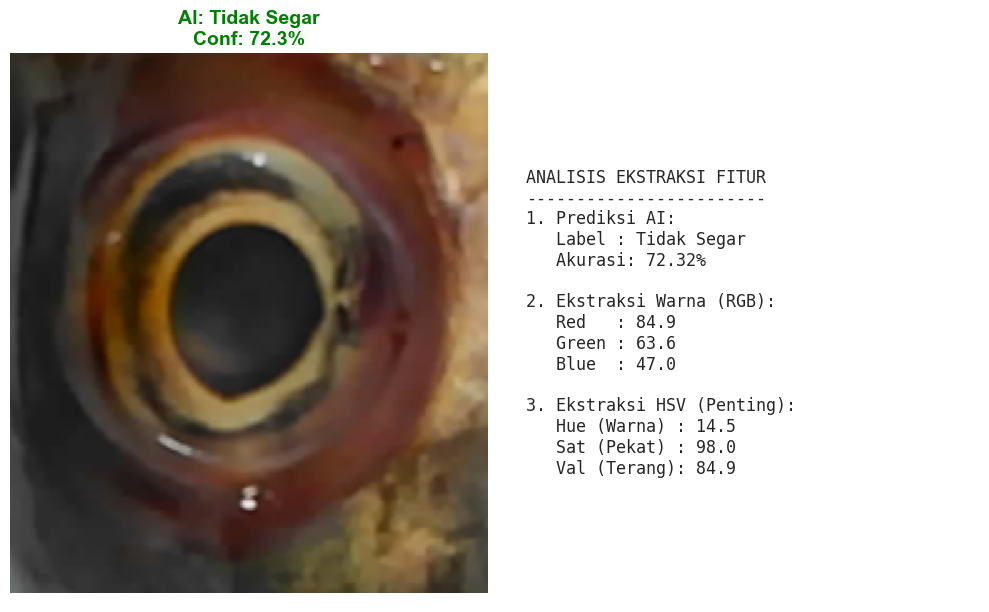


HASIL ANALISIS LENGKAP
Prediksi AI : Tidak Segar (72.32%)
Rata-rata RGB: (84.9, 63.6, 47.0)
Rata-rata HSV: (14.5, 98.0, 84.9)


In [9]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import cv2  # Kita gunakan OpenCV untuk konversi warna yang akurat
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tkinter import Tk, filedialog

# ==========================================
# 1. KONFIGURASI
# ==========================================
MODEL_PATH = r'Exp2_DenseNet121_Texture_best_model.keras' # Sesuaikan path
IMG_SIZE = (224, 224)
CLASS_NAMES = ['Segar', 'Tidak Segar'] 

# ==========================================
# 2. FUNGSI EKSTRAKSI FITUR (RGB & LAINNYA)
# ==========================================
def extract_color_features(image_path):
    """
    Menghitung rata-rata nilai RGB dan HSV dari gambar.
    """
    # Baca gambar menggunakan OpenCV (format BGR default)
    img_bgr = cv2.imread(image_path)
    # Ubah ke RGB (karena OpenCV pakai BGR, Matplotlib pakai RGB)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    # Ubah ke HSV (Hue, Saturation, Value) - Sangat bagus untuk deteksi kesegaran
    img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    
    # 1. Hitung Rata-rata RGB
    mean_r = np.mean(img_rgb[:, :, 0])
    mean_g = np.mean(img_rgb[:, :, 1])
    mean_b = np.mean(img_rgb[:, :, 2])
    
    # 2. Hitung Rata-rata HSV
    # Hue: Jenis warna (0-179), Saturation: Kepekatan (0-255), Value: Kecerahan (0-255)
    mean_h = np.mean(img_hsv[:, :, 0])
    mean_s = np.mean(img_hsv[:, :, 1])
    mean_v = np.mean(img_hsv[:, :, 2])
    
    return {
        'R': mean_r, 'G': mean_g, 'B': mean_b,
        'H': mean_h, 'S': mean_s, 'V': mean_v,
        'img_rgb': img_rgb # Kembalikan gambar array untuk ditampilkan
    }

# ==========================================
# 3. FUNGSI PREDIKSI UTAMA
# ==========================================
def predict_and_analyze(model_path):
    # Load Model
    print("Memuat model...")
    try:
        model = tf.keras.models.load_model(model_path)
        print("Model berhasil dimuat!")
    except Exception as e:
        print(f"Gagal memuat model: {e}")
        return

    # Pilih File
    root = Tk()
    root.withdraw()
    file_path = filedialog.askopenfilename(title="Pilih Gambar Ikan/Minyak")
    root.destroy()
    
    if not file_path:
        print("Tidak ada file yang dipilih.")
        return

    try:
        # A. Analisis Fitur Manual (RGB, dll)
        features = extract_color_features(file_path)
        
        # B. Preprocessing untuk AI
        img = load_img(file_path, target_size=IMG_SIZE)
        x = img_to_array(img)
        x = x / 255.0  # Normalisasi (PENTING!)
        x = np.expand_dims(x, axis=0) # Tambah batch dimension

        # C. Prediksi AI
        predictions = model.predict(x)
        
        # Logika output (Cek apakah Binary Sigmoid atau Categorical Softmax)
        if predictions.shape[-1] == 1:
            # Jika Binary (Sigmoid)
            score = predictions[0][0]
            predicted_label = CLASS_NAMES[1] if score > 0.5 else CLASS_NAMES[0]
            confidence = score * 100 if score > 0.5 else (1 - score) * 100
        else:
            # Jika Categorical (Softmax)
            score_array = tf.nn.softmax(predictions[0])
            idx = np.argmax(score_array)
            predicted_label = CLASS_NAMES[idx]
            confidence = np.max(score_array) * 100

        # ==========================================
        # 4. VISUALISASI LENGKAP
        # ==========================================
        plt.figure(figsize=(10, 6))
        
        # Plot Gambar
        plt.subplot(1, 2, 1)
        plt.imshow(features['img_rgb'])
        plt.axis('off')
        
        # Judul Gambar (Hasil AI)
        color_title = 'green' if 'Segar' in predicted_label else 'red'
        plt.title(f"AI: {predicted_label}\nConf: {confidence:.1f}%", 
                  color=color_title, fontsize=14, weight='bold')

        # Plot Statistik (Text Info)
        plt.subplot(1, 2, 2)
        plt.axis('off')
        
        # Teks Statistik
        info_text = (
            f"ANALISIS EKSTRAKSI FITUR\n"
            f"------------------------\n"
            f"1. Prediksi AI:\n"
            f"   Label : {predicted_label}\n"
            f"   Akurasi: {confidence:.2f}%\n\n"
            
            f"2. Ekstraksi Warna (RGB):\n"
            f"   Red   : {features['R']:.1f}\n"
            f"   Green : {features['G']:.1f}\n"
            f"   Blue  : {features['B']:.1f}\n\n"
            
            f"3. Ekstraksi HSV (Penting):\n"
            f"   Hue (Warna) : {features['H']:.1f}\n"
            f"   Sat (Pekat) : {features['S']:.1f}\n"
            f"   Val (Terang): {features['V']:.1f}"
        )
        
        plt.text(0.05, 0.5, info_text, fontsize=12, family='monospace', verticalalignment='center')
        plt.tight_layout()
        plt.show()

        # Print ke Console juga
        print("\n" + "="*30)
        print("HASIL ANALISIS LENGKAP")
        print("="*30)
        print(f"Prediksi AI : {predicted_label} ({confidence:.2f}%)")
        print(f"Rata-rata RGB: ({features['R']:.1f}, {features['G']:.1f}, {features['B']:.1f})")
        print(f"Rata-rata HSV: ({features['H']:.1f}, {features['S']:.1f}, {features['V']:.1f})")

    except Exception as e:
        print(f"Terjadi kesalahan: {e}")

# Jalankan Program
if __name__ == "__main__":
    predict_and_analyze(MODEL_PATH)